In [ ]:
from google.colab import drive
try:
  import awkward as ak
except:
  !pip install awkward
  import awkward as ak
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import gamma

drive.mount('/content/drive')

#Single chunk to do some analysis. It was made for every single chunk to check if the data was loaded correctly and to check if the data were correctly shufffled.
parquet_path = "/content/drive/MyDrive/parquet_chunks/chunk_0.parquet"

Mounted at /content/drive


In [ ]:
events = ak.from_parquet(parquet_path)

print(f"Dataset loaded from: {parquet_path}")
print(f"Total number of events: {len(events)}")
print(f"Features: {events.fields}")

Dataset caricato
Numero totale di eventi: 100000
variiabili: ['energy', 'x', 'y', 'z', 'target']


In [ ]:
event_idx = 99999
print(f"Event {event_idx} info:")
print(f"Number of hits: {len(events[event_idx].x)}")
print(f"Hit x: {events[event_idx].x}")
print(f"Hit y: {events[event_idx].y}")
print(f"Hit z: {events[event_idx].z}")
print(f"Hit energy: {events[event_idx].energy}")
print(f"Target energy: {events[event_idx].target}")

Evento 99999 info:
Numero di hit: 1138
Hit x: [-0.972, -1.94, -1.94, -0.972, -1.94, ..., -1.94, -3.89, -4.86, -4.86, 0.972]
Hit y: [1.68, 2.24, 1.12, 2.81, 1.12, 2.24, ..., 3.37, 0, 1.12, 1.68, 0.561, 2.81]
Hit z: [13.9, 13.9, 13.9, 14.8, 14.8, 16.8, ..., 53.9, 53.9, 53.9, 53.9, 53.9, 53.9]
Hit energy: [1.94, 3.83, 5.61, 1.99, 26.7, 3.01, ..., 1.05, 6.52, 15.6, 0.691, 18.5, 1.11]
Target energy: [316, 316, 316, 316, 316, 316, 316, 316, ..., 316, 316, 316, 316, 316, 316, 316]


In [ ]:
total_hits = ak.num(events.energy, axis=1)

print(f"Average number of hits: {np.mean(total_hits):.2f}")
print(f"Event with most hits idx: {np.argmax(total_hits)}, with {np.max(total_hits)} hits")

Numero medio di hit: 799.64
Evento con più hit idx :9697, con 1376 hits


In [ ]:
print(f"Max and min {event_idx}: {np.max(events[event_idx].z)} --- {np.min(events[event_idx].z)}")
print(f"Max and min global: {np.max(events.z)} --- {np.min(events.z)}")
zlayers_coordinate = np.unique(ak.flatten(events.z))
print(f"Z layers coordinates in cm: {zlayers_coordinate}, {len(zlayers_coordinate)} layers")

Max e min evento 99999: 53.903499603271484 --- 13.8774995803833
Max e min globali: 53.903499603271484 --- 13.8774995803833
Z layers coordinate in cm: [13.9, 14.8, 16.8, 17.7, 19.7, 20.6, ..., 46.4, 47.5, 49.7, 50.7, 52.9, 53.9], in totale 28 layers


In [ ]:
z_hits_single_event = events[event_idx].z
energy_single_event = events[event_idx].energy

energy_distr = np.zeros(len(zlayers_coordinate))

for i, elem in enumerate(zlayers_coordinate):
  mask = z_hits_single_event == elem
  energy = np.sum(energy_single_event[mask])
  energy_distr[i] = np.sum(energy_single_event[mask])

print(f"Energy per layer: {energy_distr}")


Energia in layer: [  11.38933372   28.70186615   50.76818085  196.82887268  490.14093018
  991.2376709  1564.92053223 1912.66796875 2485.63183594 2767.84277344
 3145.99462891 2852.49560547 2853.88818359 2343.59716797 2075.78515625
 1597.64404297 1625.43908691 1028.17236328  859.34521484  606.48345947
  372.3416748   318.26870728  276.54412842  202.38552856  141.06335449
  135.50584412  115.77854919   54.67236328]


<>:37: SyntaxWarning: invalid escape sequence '\,'
<>:37: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_191/1252498374.py:37: SyntaxWarning: invalid escape sequence '\,'
  plt.axvline(t_max, color='green', linestyle='--', alpha=0.7, label=f'Peak at $t_{{max}} = {t_max:.2f} \, X_0$')


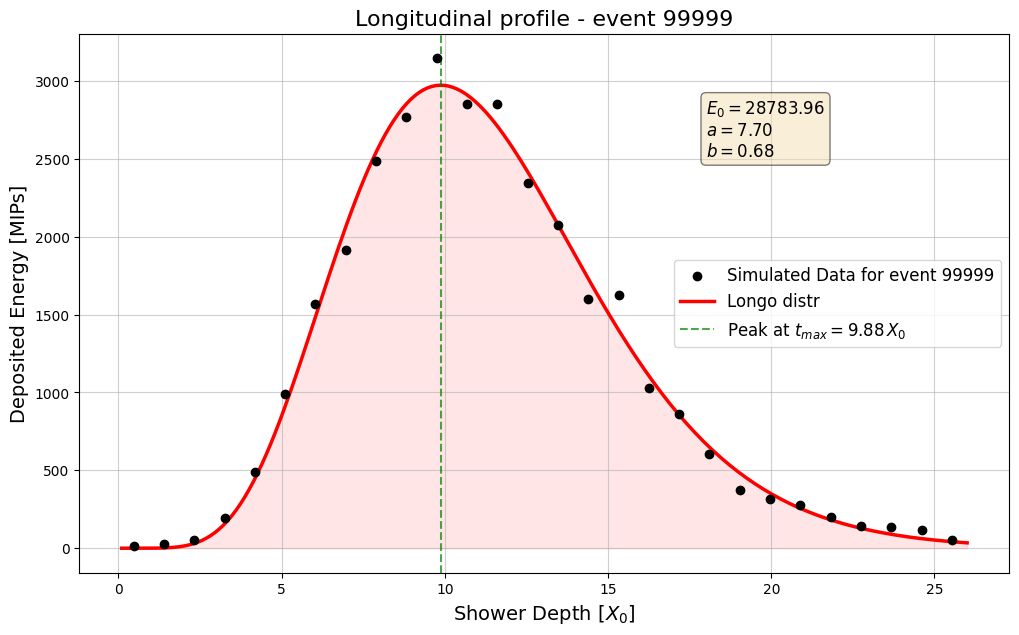

In [ ]:
total_x0 = 26.0
n_layers = 28
x0_per_layer = total_x0 / n_layers
t_x0 = np.arange(1, n_layers + 1) * x0_per_layer - (x0_per_layer / 2) #Units in rad lenght

#Longo model
def longo_modello(t, E0, a, b): 
    t = np.where(t <= 0, 1e-3, t)
    return E0 * ( (b**(a) * t**(a-1) * np.exp(-b*t)) / gamma(a) )

p0 = [np.sum(energy_distr), 7.0, 0.5]
popt, pcov = curve_fit(longo_modello, t_x0, energy_distr, p0=p0)
E0_fit, a_fit, b_fit = popt
t_max = (a_fit - 1) / b_fit

plt.figure(figsize=(12, 7))

plt.scatter(t_x0, energy_distr, color='black', label=f'Simulated Data for event {event_idx}', zorder=3)
t_space = np.linspace(0.1, 26, 200)
y_fit = longo_modello(t_space, *popt)
plt.plot(t_space, y_fit, color='red', linewidth=2.5, label='Longo distr')
plt.fill_between(t_space, y_fit, color='red', alpha=0.1)


plt.axvline(t_max, color='green', linestyle='--', alpha=0.7, label=f'Peak at $t_{{max}} = {t_max:.2f} \, X_0$')

plt.title(f'Longitudinal profile - event {event_idx}', fontsize=16)
plt.xlabel('Shower Depth [$X_0$]', fontsize=14)
plt.ylabel('Deposited Energy [MIPs]', fontsize=14)
plt.grid(True, alpha=0.6)
plt.legend(fontsize=12)

textstr = '\n'.join((
    r'$E_0=%.2f$' % (E0_fit, ),
    r'$a=%.2f$' % (a_fit, ),
    r'$b=%.2f$' % (b_fit, )))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(18, np.max(energy_distr)*0.8, textstr, fontsize=12, bbox=props)

plt.show()

In [ ]:
print(len(np.unique(ak.flatten(events.target))))
print(len(events.target[0]))

98859
1115


/tmp/ipykernel_191/1252498374.py:16: RuntimeWarning: invalid value encountered in scalar power
  return E0 * ( (b**(a) * t**(a-1) * np.exp(-b*t)) / gamma(a) )


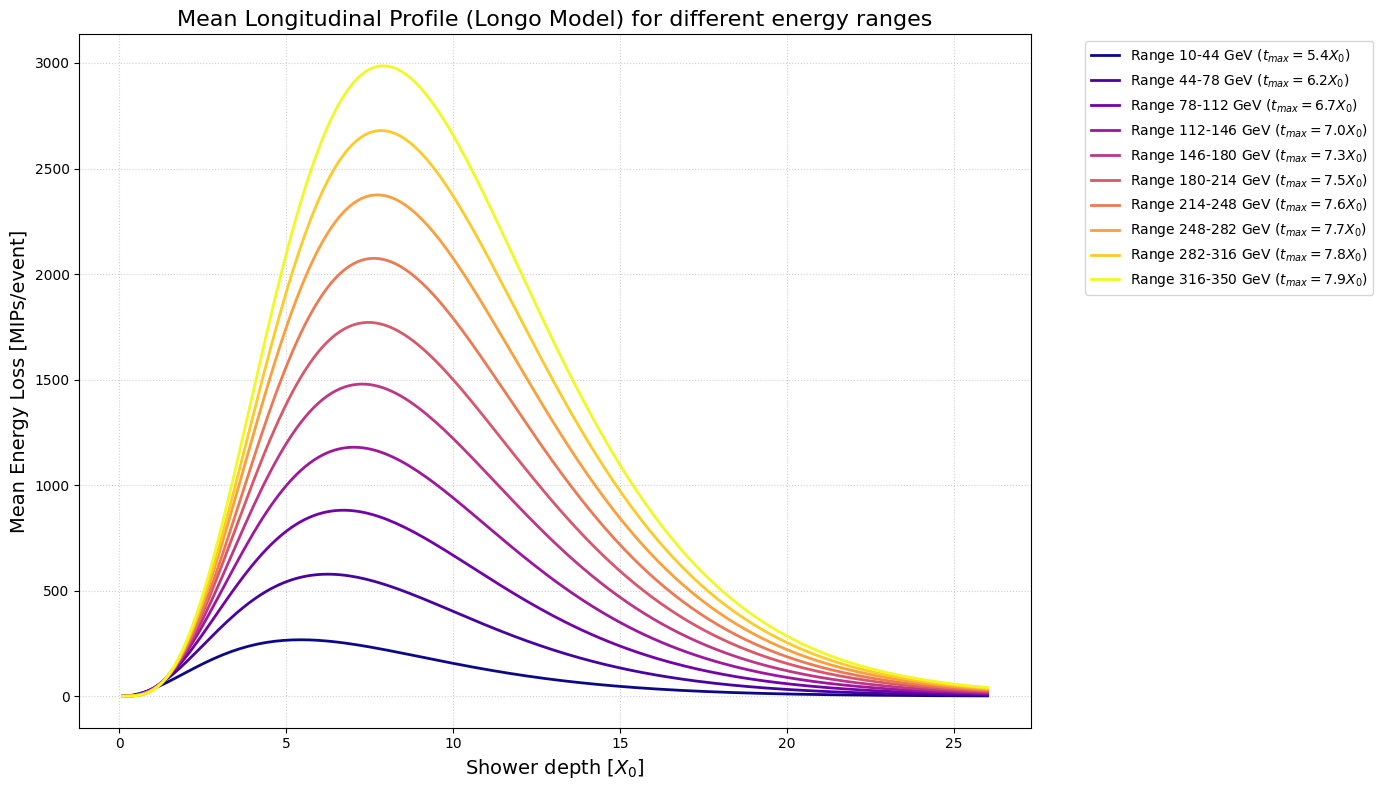

In [ ]:
#Longo model for different energy ranges, to check how the parameters change with energy and how the peak changes with energy.
target_all = ak.to_numpy(events.target[:, 0])

e_min, e_max = target_all.min(), target_all.max()
z_np = ak.to_numpy(zlayers_coordinate)
z_min, z_max = z_np.min(), z_np.max()

bin_edges = np.linspace(e_min, e_max, 11)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mean_profiles = []
fit_params = []
for i in range(10):
    low, high = bin_edges[i], bin_edges[i+1]
    mask = (target_all >= low) & (target_all < high)
    ids = np.where(mask)[0]

    if len(ids) > 0:
        subset = events[ids]
        all_z = ak.flatten(subset.z)
        all_e = ak.flatten(subset.energy)

        sum_e, _ = np.histogram(all_z, bins=28,
                                range=(z_min, z_max),
                                weights=all_e)

        profile_medio = sum_e / len(ids)
        mean_profiles.append(profile_medio)


        p0 = [np.sum(profile_medio), 7.0, 0.5]
        popt, _ = curve_fit(longo_modello, t_x0, profile_medio, p0=p0, maxfev=5000)
        fit_params.append(popt)

plt.figure(figsize=(14, 8))
colors = plt.cm.plasma(np.linspace(0, 1, 10))
t_smooth = np.linspace(0.1, 26, 200)

for i in range(10):
      popt = fit_params[i]
      t_max = (popt[1] - 1) / popt[2]

      y_fit = longo_modello(t_smooth, *popt)
      plt.plot(t_smooth, y_fit, color=colors[i], linewidth=2,
                label=f"Range {bin_edges[i]:.0f}-{bin_edges[i+1]:.0f} GeV ($t_{{max}}={t_max:.1f} X_0$)")

plt.title("Mean Longitudinal Profile (Longo Model) for different energy ranges", fontsize=16)
plt.xlabel(r"Shower depth [$X_0$]", fontsize=14)
plt.ylabel("Mean Energy Loss [MIPs/event]", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

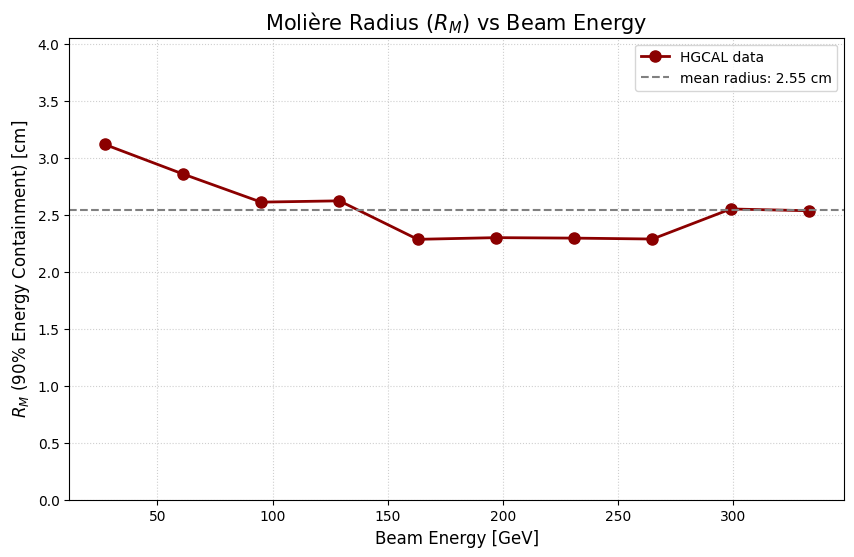

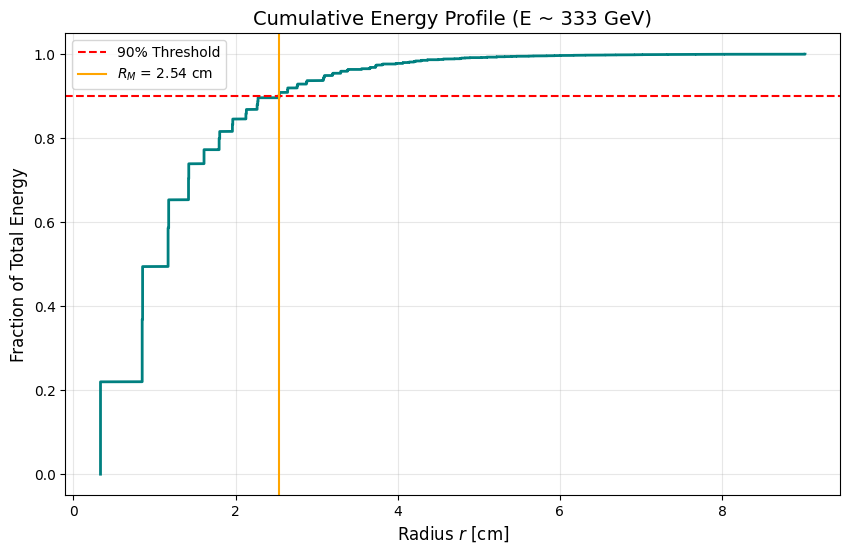

In [ ]:
#Moliere radius for different energy ranges, to check how it changes with energy. Must be double checked.
rm_list = []
energy_centers = []

for i in range(10):
    low, high = bin_edges[i], bin_edges[i+1]
    mask = (target_all >= low) & (target_all < high)
    ids = np.where(mask)[0]

    if len(ids) > 10:

        subset = events[ids]
        all_x = ak.flatten(subset.x)
        all_y = ak.flatten(subset.y)
        all_e = ak.flatten(subset.energy)


        x0 = np.sum(all_x * all_e) / np.sum(all_e)
        y0 = np.sum(all_y * all_e) / np.sum(all_e)


        r = np.sqrt((all_x - x0)**2 + (all_y - y0)**2)


        idx_sort = np.argsort(r)
        r_sorted = r[idx_sort]
        e_cumulative = np.cumsum(all_e[idx_sort])


        e_total = e_cumulative[-1]

        rm = np.interp(0.9 * e_total, e_cumulative, r_sorted)

        rm_list.append(rm)
        energy_centers.append(bin_centers[i])


plt.figure(figsize=(10, 6))
plt.plot(energy_centers, rm_list, 'o-', color='darkred', markersize=8, linewidth=2, label='HGCAL data')
plt.axhline(np.mean(rm_list), color='gray', linestyle='--', label=f'mean radius: {np.mean(rm_list):.2f} cm')

plt.title("Molière Radius ($R_M$) vs Beam Energy", fontsize=15)
plt.xlabel("Beam Energy [GeV]", fontsize=12)
plt.ylabel("$R_M$ (90% Energy Containment) [cm]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, max(rm_list)*1.3)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(r_sorted, e_cumulative / e_total, color='teal', linewidth=2)
plt.axhline(0.9, color='red', linestyle='--', label='90% Threshold')
plt.axvline(rm, color='orange', linestyle='-', label=f'$R_M$ = {rm:.2f} cm')
plt.title(f"Cumulative Energy Profile (E ~ {energy_centers[-1]:.0f} GeV)", fontsize=14)
plt.xlabel("Radius $r$ [cm]", fontsize=12)
plt.ylabel("Fraction of Total Energy", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(target_all.shape)
print(target_all)
print(len(target_all))

(100000,)
[286.60654 260.23077 122.32089 ...  46.21762 190.9066  316.43695]
100000


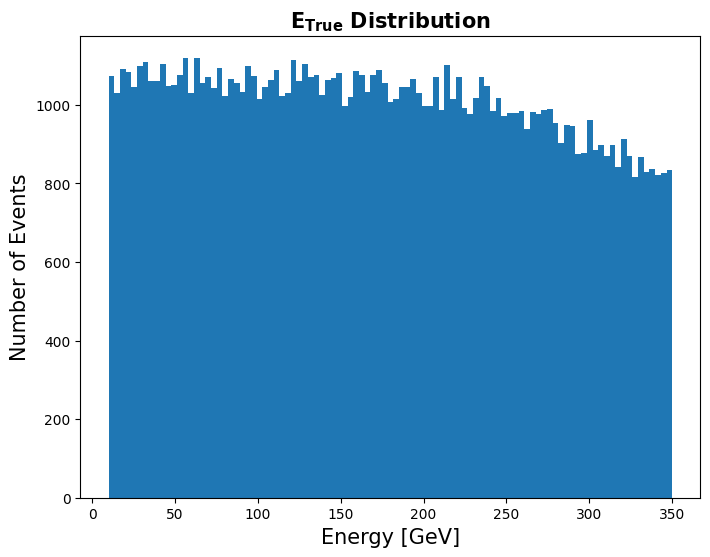

In [ ]:
#Target distribution
energy_space = np.linspace(target_all.min(), target_all.max(), 100)
plt.figure(figsize = (8, 6))
plt.hist(target_all, energy_space)
plt.title(r"$\mathbf{E_{True}}$ Distribution", fontweight = "bold", fontsize = 15)
plt.xlabel("Energy [GeV]", fontsize = 15)
plt.ylabel("Number of Events",fontsize = 15)
plt.show()


In [ ]:
energy_all = ak.to_numpy(ak.flatten(events.energy))
x_numpy = ak.to_numpy(ak.flatten(events.x))
y_numpy = ak.to_numpy(ak.flatten(events.y))
z_numpy = ak.to_numpy(ak.flatten(events.z))
energy_per_event = ak.to_numpy(ak.sum(events.energy, axis=1))
energy_per_event.shape
print(energy_per_event)



[28207.7    25848.078  11977.655  ...  4463.6836 18965.496  31105.514 ]


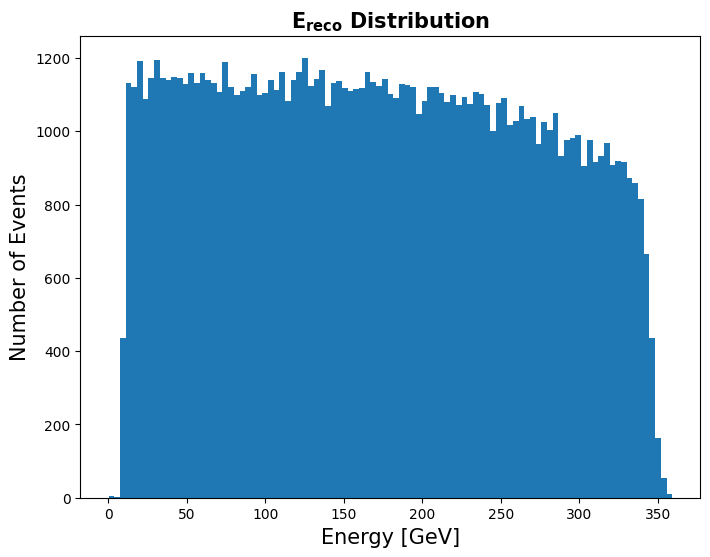

In [ ]:
#Energy reco distribution
energy_space_rec = np.linspace(energy_per_event.min()*0.01, energy_per_event.max()*0.01, 100)
plt.figure(figsize = (8, 6))
plt.hist(energy_per_event*0.01, energy_space_rec)
plt.title(r"$\mathbf{E_{reco}}$ Distribution", fontweight = "bold", fontsize = 15)
plt.xlabel("Energy [GeV]", fontsize = 15)
plt.ylabel("Number of Events", fontsize = 15)
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_191/2471748524.py:12: SyntaxWarning: invalid escape sequence '\m'
  label= f'$\mu$ = {mean:.2f}')


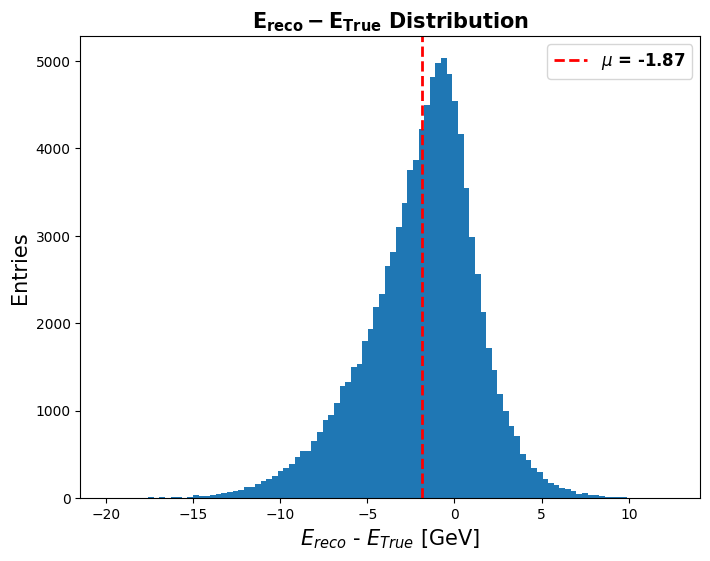

In [ ]:
diff = energy_per_event*0.01 - target_all
mask =  (energy_per_event*0.01 - target_all > -20)
diff_limited = diff[mask]
mean = np.mean(diff_limited)
std = np.std(diff_limited)
plt.figure(figsize = (8, 6))
plt.hist(diff_limited, 100)
plt.axvline(x=mean,
            color='red',
            linestyle='--',
            linewidth=2,
            label= f'$\mu$ = {mean:.2f}')
plt.xlabel("$E_{reco}$ - $E_{True}$ [GeV]", fontsize=15)
plt.ylabel("Entries", fontsize=15)
plt.title(r"$\mathbf{E_{reco} - E_{True}}$ Distribution", fontsize=15, fontweight='bold')
plt.legend(prop={'size': 12, 'weight': 'bold'})
plt.show()

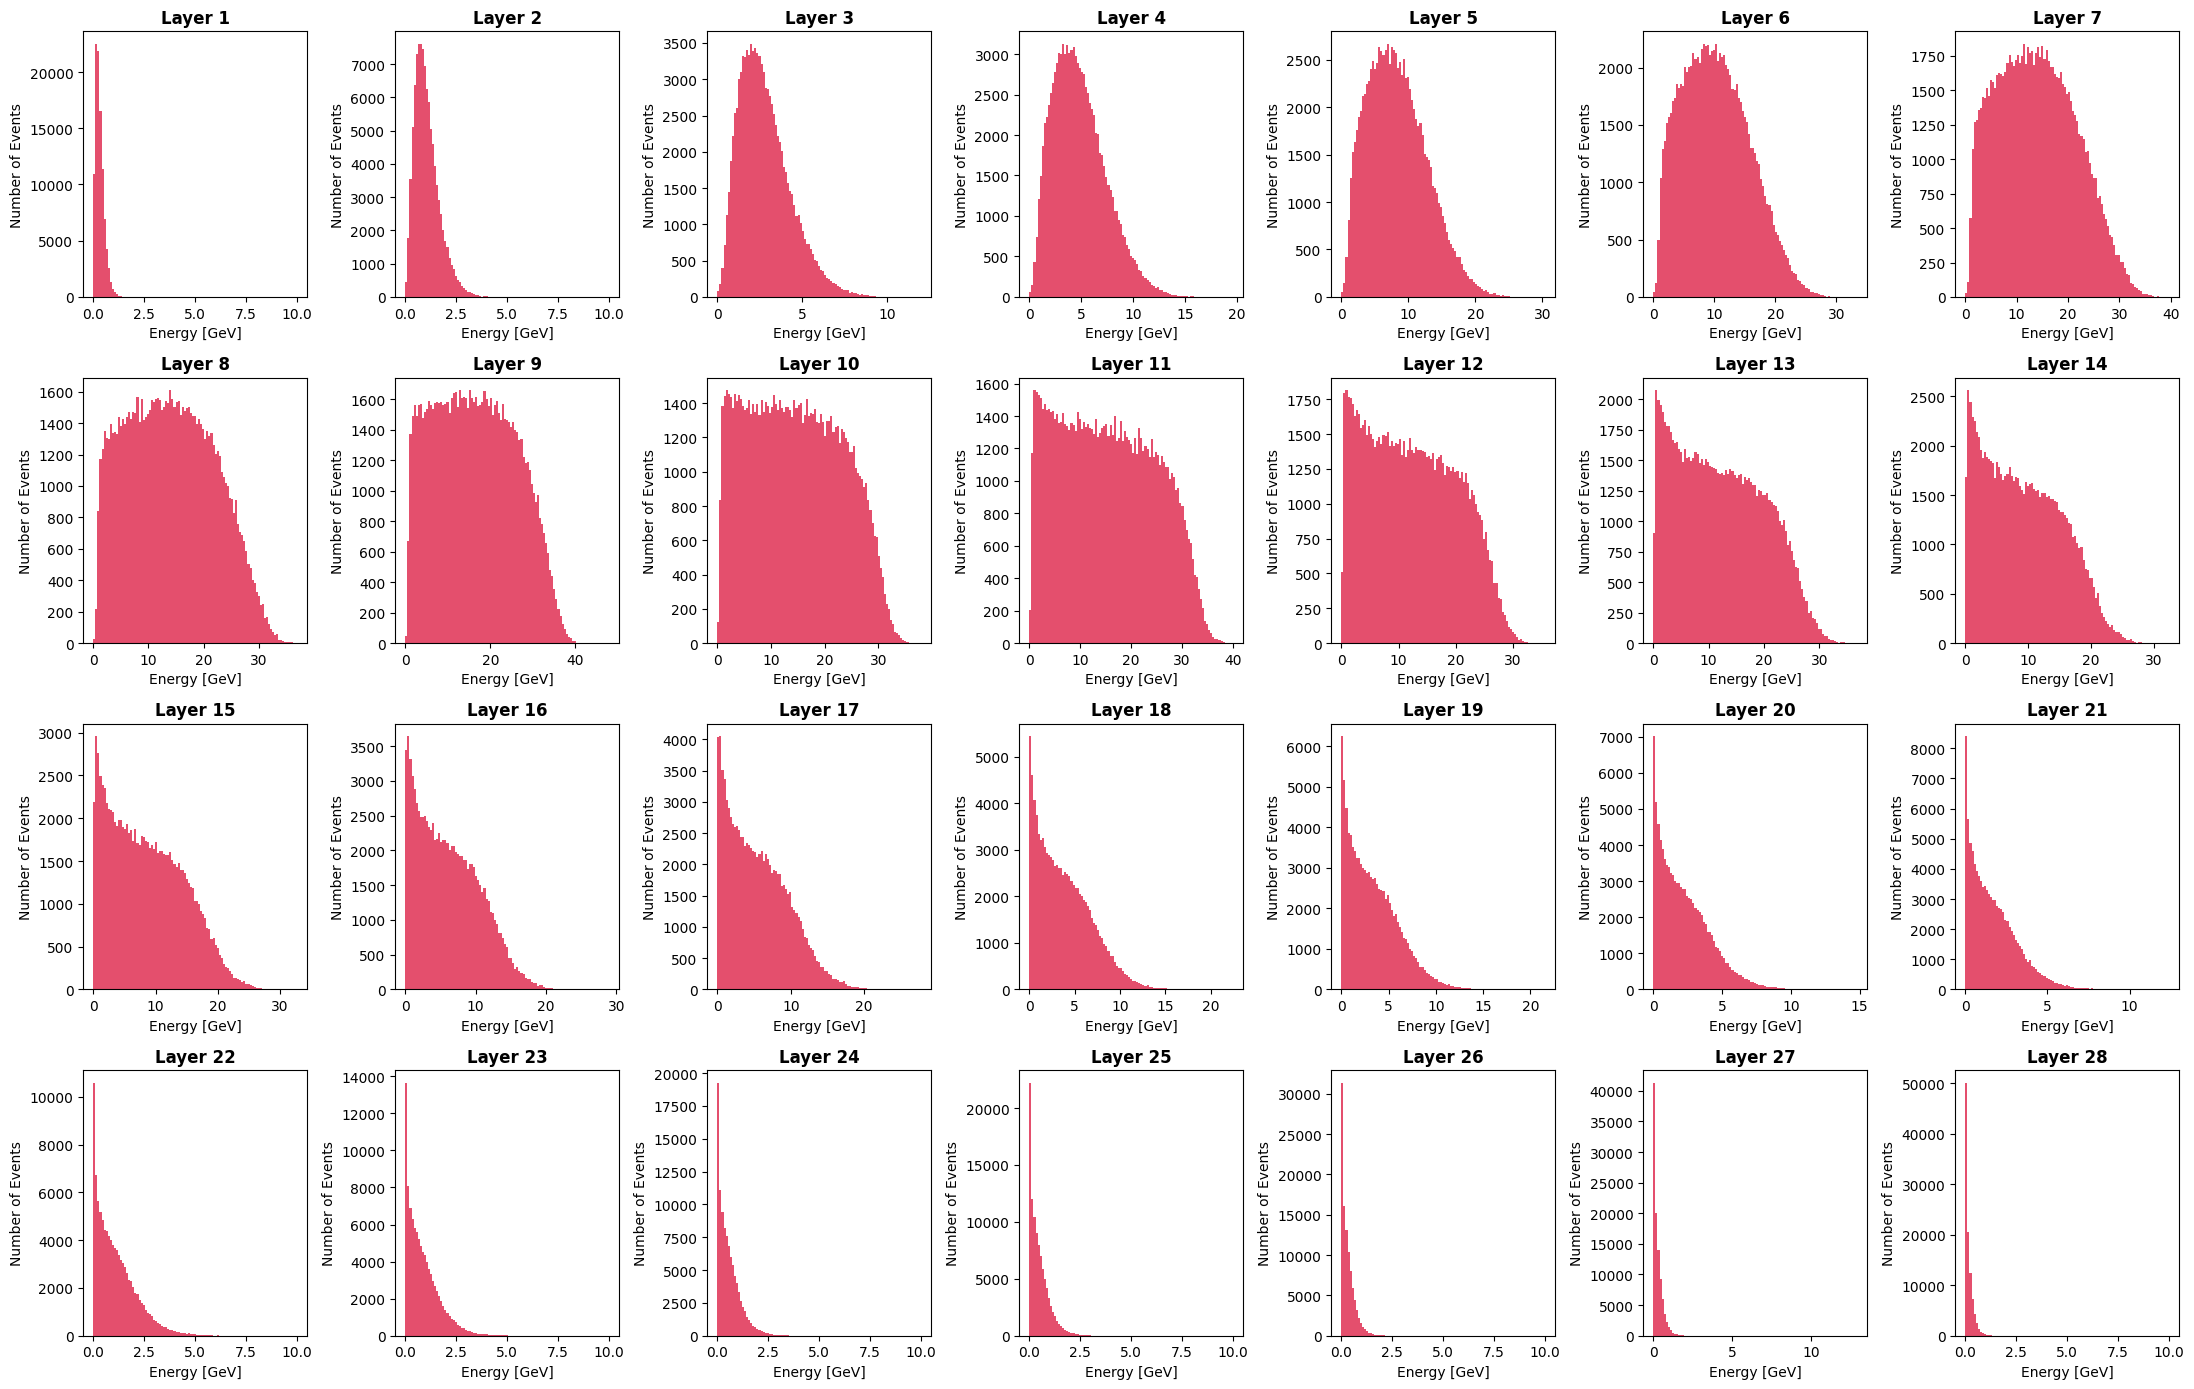

In [ ]:
#Visual plot of energy distribution per layer, to check if the layers are correctly ordered and if the energy distribution is reasonable.
fig, axes = plt.subplots(4, 7, figsize=(22, 14))
axes = axes.flatten()
j = 0
for i, z in enumerate(z_values):
  mask = events.z == z
  energy_per_layer = ak.sum(events.energy[mask]*0.01, axis=-1)
  energy_to_plot = ak.to_numpy(energy_per_layer)
  energy_space_per_layer = np.linspace(energy_to_plot.min(), max(energy_to_plot.max(), 10), 100)
  axes[i].hist(energy_to_plot, energy_space_per_layer, color = "crimson", alpha = 0.75)
  axes[i].set_xlabel("Energy [GeV]")
  axes[i].set_ylabel("Number of Events")
  axes[i].set_title(f"Layer {i + 1}", fontweight='bold')
plt.tight_layout()
plt.show()


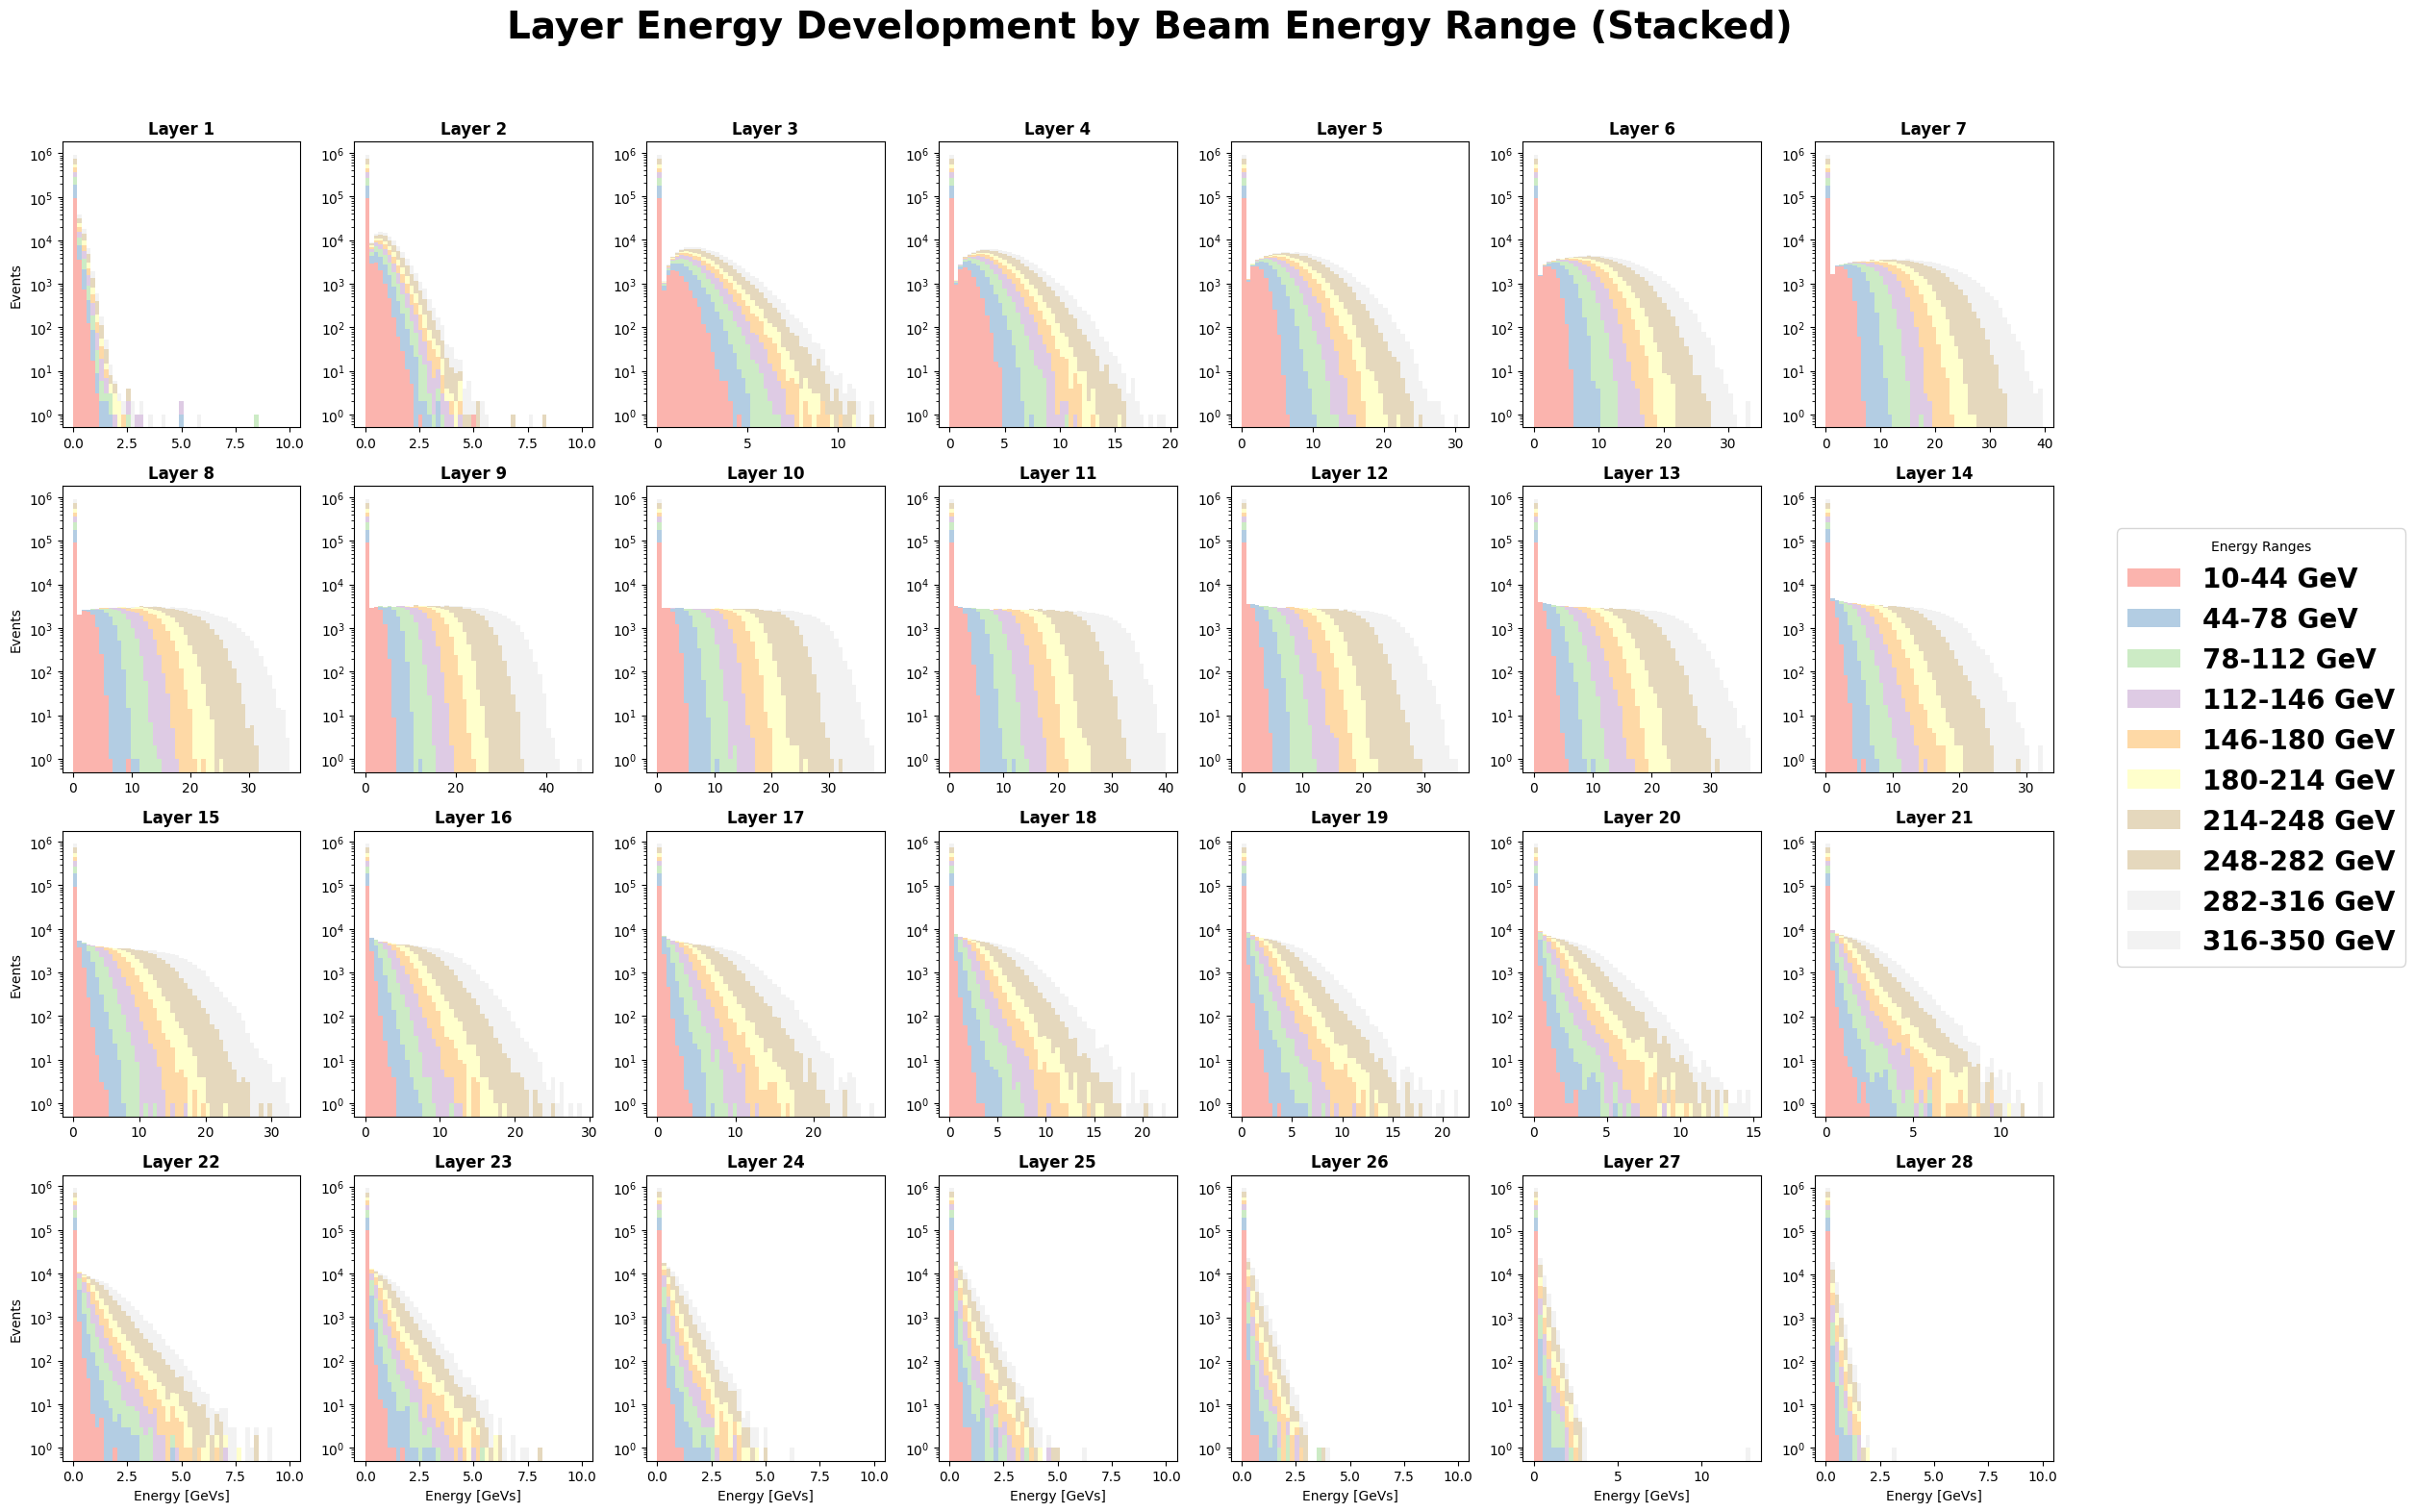

In [ ]:
#Same plot but stacked to see the development of the shower with depth and to check if the energy distribution changes with the beam energy.
n_bins_energy = 10
energy_bins = np.linspace(target_all.min(), target_all.max(), n_bins_energy + 1)
event_bin_indices = np.digitize(target_all, energy_bins)

fig, axes = plt.subplots(4, 7, figsize=(24, 16))
axes = axes.flatten()
colors = plt.cm.Pastel1(np.linspace(0, 1, n_bins_energy))

for i, z in enumerate(z_values):
    ax = axes[i]
    mask_z = (events.z == z)
    stacked_data = []
    labels = []

    for b in range(1, n_bins_energy + 1):
        mask_energy = (event_bin_indices == b)
        e_layer = ak.sum(events.energy[mask_z & mask_energy]*0.01, axis=-1)
        stacked_data.append(ak.to_numpy(e_layer))
        labels.append(f"{energy_bins[b-1]:.0f}-{energy_bins[b]:.0f} GeV")
    all_layer_data = ak.to_numpy(ak.sum(events.energy[mask_z]*0.01, axis=-1))
    bins_hist = np.linspace(0, max(all_layer_data.max(), 10), 50)
    ax.hist(stacked_data, bins=bins_hist, stacked=True, color=colors,
            label=labels if i == 0 else None, alpha=1)

    ax.set_title(f"Layer {i+1}", fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    if i >= 21: ax.set_xlabel("Energy [GeVs]")
    if i % 7 == 0: ax.set_ylabel("Events")

fig.legend(loc='center right', title="Energy Ranges", bbox_to_anchor=(1.05, 0.5), prop={'size': 20, 'weight': 'bold'})

plt.suptitle("Layer Energy Development by Beam Energy Range (Stacked)", fontsize=28, y=0.98, fontweight = "bold")
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()